In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [9]:
data=pd.read_csv('/hotel_booking.csv')

In [10]:
print(data.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  customer_type  \
0                        0                     0       2  ...      Transient   
1   

In [12]:
data.shape

(119390, 36)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [15]:
data.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [16]:
data.drop(columns=["agent","company"],inplace=True)

In [17]:
data.dropna(inplace=True)

In [19]:
data.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [21]:
data.duplicated().sum()

0

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118898 entries, 0 to 119389
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118898 non-null  object 
 1   is_canceled                     118898 non-null  int64  
 2   lead_time                       118898 non-null  int64  
 3   arrival_date_year               118898 non-null  int64  
 4   arrival_date_month              118898 non-null  object 
 5   arrival_date_week_number        118898 non-null  int64  
 6   arrival_date_day_of_month       118898 non-null  int64  
 7   stays_in_weekend_nights         118898 non-null  int64  
 8   stays_in_week_nights            118898 non-null  int64  
 9   adults                          118898 non-null  int64  
 10  children                        118898 non-null  float64
 11  babies                          118898 non-null  int64  
 12  meal                 

In [23]:
data["reservation_status_date"]=pd.to_datetime(data["reservation_status_date"])

In [24]:
data.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,name,email,phone-number,credit_card
count,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898,118898
unique,2,12,5,177,7,5,10,12,3,4,3,81234,115425,118898,9000
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,Robert Smith,Michael.C@gmail.com,669-792-1661,************3627
freq,79302,13852,91863,48586,56402,97730,85601,73863,104163,89174,74745,48,6,1,28


In [25]:
data.drop(columns=["name","email","phone-number","credit_card","meal","arrival_date_week_number"],inplace=True,errors='ignore')

In [27]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [28]:
for x in data.describe(include='object'):
    print(x)
    print(data[x].unique())
    print("*"*60)

hotel
['Resort Hotel' 'City Hotel']
************************************************************
arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
************************************************************
country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' 'ROU' 'NOR' 'OMN' 'ARG' 'POL' 'DEU'
 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST' 'CZE'
 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR' 'UKR'
 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO' 'ISR'
 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM' 'HRV'
 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY' 'KWT'
 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN' 'SYC'
 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB' 'CMR'
 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'JOR' 'SYR' 'SGP' 'BDI' 'SAU'
 'VNM' 'PLW' 'QAT' 'EGY' 'PER' 'MLT' 'MWI' 'EC

In [29]:
data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2016.157656,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2016-07-30 07:37:53.336809984
min,0.000000,0.000000,2015.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483168,106.903309,0.707459,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


<Axes: ylabel='adr'>

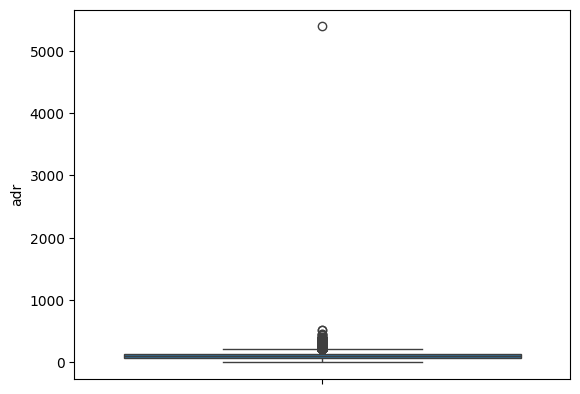

In [30]:
sns.boxplot(data=data,y="adr")

In [31]:
data = data[data['adr'] < 5000]

In [32]:
data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897
mean,0.371347,104.312018,2016.157657,15.800802,0.928905,2.502157,1.858390,0.104208,0.007948,0.032011,0.087143,0.131635,0.221175,2.330774,101.958683,0.061885,0.571688,2016-07-30 07:39:51.289939968
min,0.000000,0.000000,2015.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,510.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483167,106.903570,0.707462,8.780321,0.996217,1.900171,0.578578,0.399174,0.097381,0.176030,0.845872,1.484678,0.652784,17.630525,48.091199,0.244173,0.792680,NaN


In [33]:
cancel_data=data["is_canceled"].value_counts(True)
cancel_data

,proportion
is_canceled,
0,0.628653
1,0.371347


<ipython-input-47-5fb284b03d28>:3: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Not Canceled","Canceld"])


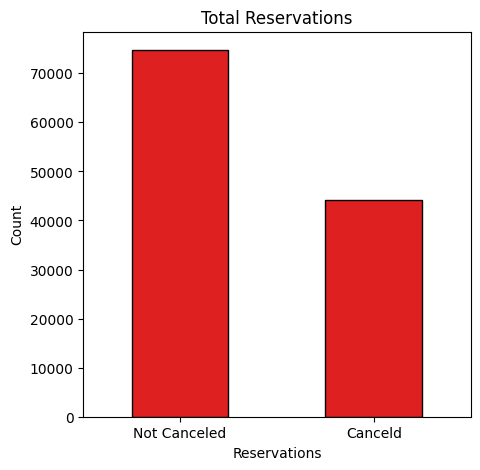

In [47]:
plt.figure(figsize=(5,5))
ax=sns.countplot(data=data,x="is_canceled",color='red',edgecolor='k',width=0.5)
ax.set_xticklabels(["Not Canceled","Canceld"])
plt.xlabel("Reservations")
plt.ylabel("Count")
plt.title("Total Reservations")
plt.show()

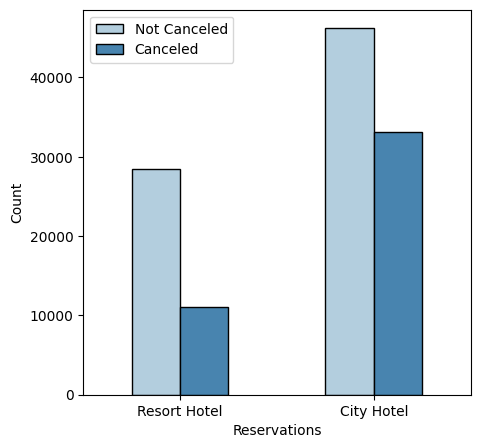

In [50]:
plt.figure(figsize=(5,5))
sns.countplot(data=data,x='hotel',hue='is_canceled',palette='Blues',width=0.5,edgecolor='black')
plt.xlabel("Reservations")
plt.ylabel("Count")
plt.legend(["Not Canceled","Canceled"])
plt.show()

              is_canceled
hotel                    
City Hotel          33075
Resort Hotel        11077


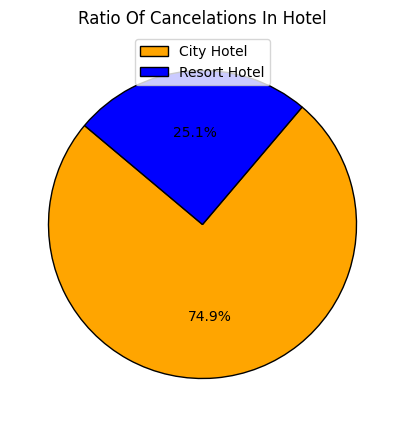

In [51]:
cancel_data=data[data["is_canceled"]==1]
group_data=cancel_data.groupby("hotel").agg({"is_canceled":"sum"})
print(group_data)

plt.figure(figsize=(5,5))
plt.pie(group_data["is_canceled"], colors=['orange', 'blue'], startangle=140,autopct="%1.1f%%",wedgeprops={"edgecolor":"black"})
plt.legend(labels=group_data.index,loc="upper center")
plt.title("Ratio Of Cancelations In Hotel")
plt.show()

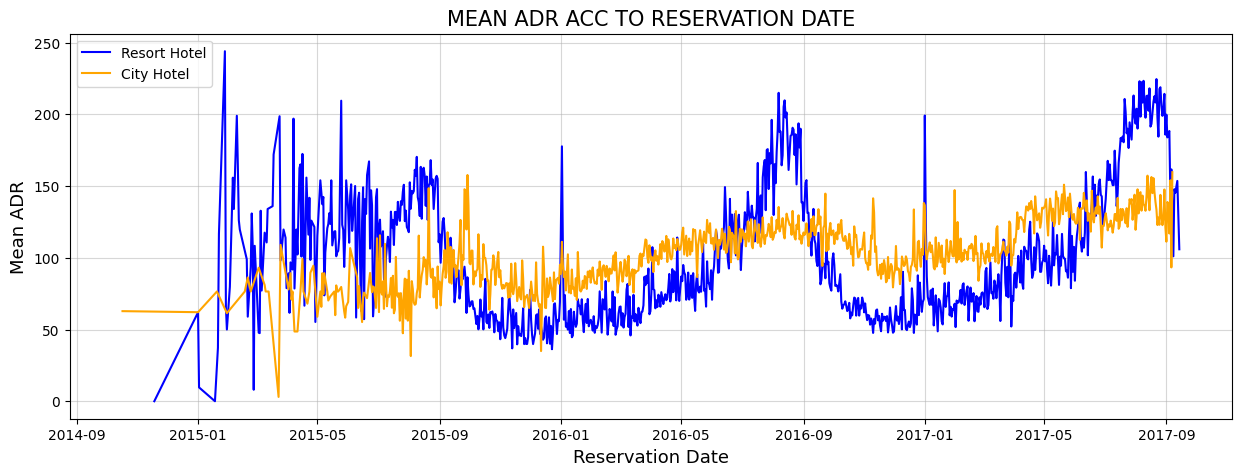

In [37]:
resort_data=data[data["hotel"]=="Resort Hotel"]
city_data=data[data["hotel"]=="City Hotel"]

resort_data=resort_data.groupby("reservation_status_date").agg({"adr":"mean"})
city_data=city_data.groupby("reservation_status_date").agg({"adr":"mean"})

plt.figure(figsize=(15,5))
plt.plot(resort_data.index,resort_data["adr"],color="blue",label="Resort Hotel")
plt.plot(city_data.index,city_data["adr"],color="orange",label="City Hotel")
plt.xlabel("Reservation Date",fontsize=13)
plt.ylabel("Mean ADR",fontsize=13)
plt.title("MEAN ADR ACC TO RESERVATION DATE",fontsize=15)
plt.legend(loc="best")
plt.grid(alpha=0.5)
plt.show()

In [38]:
import datetime as dt
data["Month"]=data["reservation_status_date"].dt.month_name()

<ipython-input-38-efc89a11311e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Month"]=data["reservation_status_date"].dt.month_name()


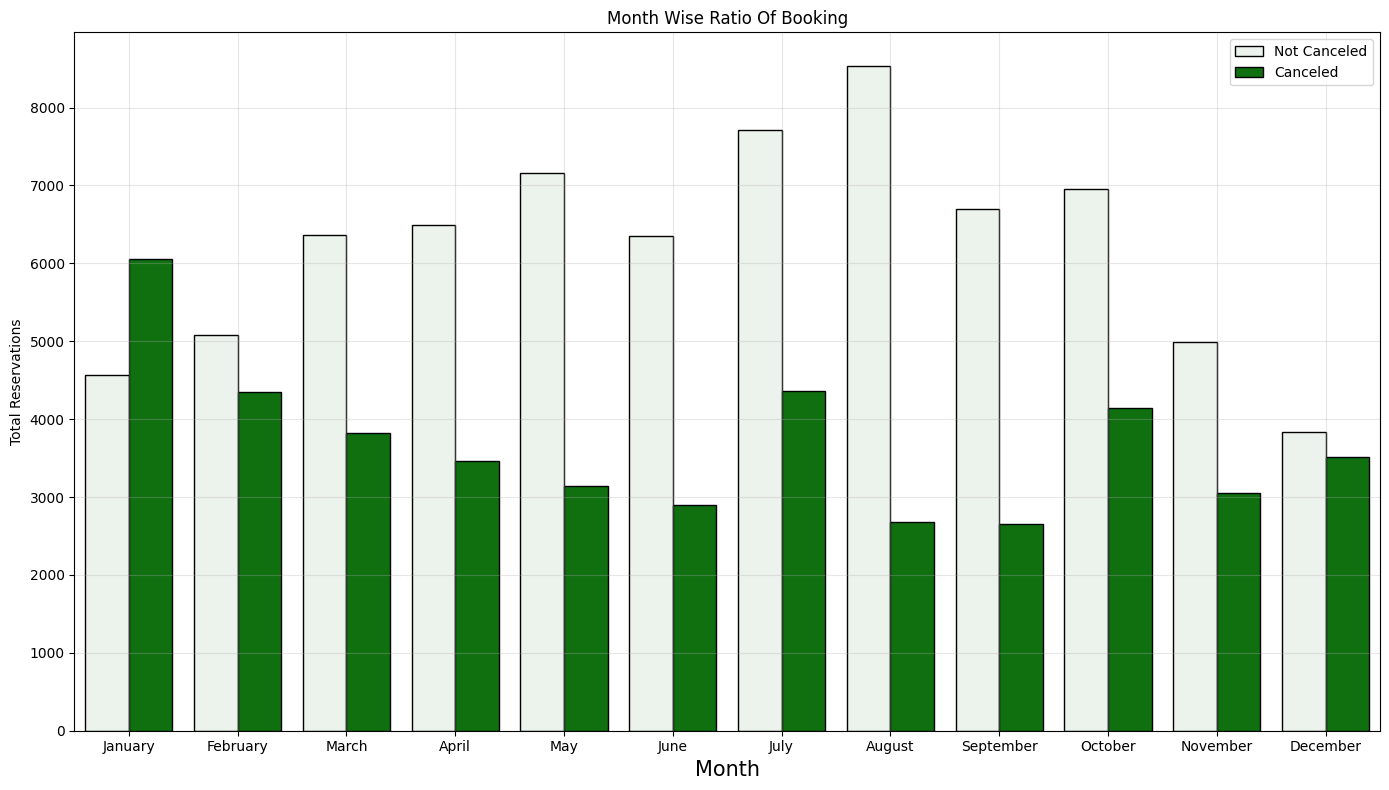

In [39]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

plt.figure(figsize=(14,8))
sns.countplot(data=data,x="Month",hue="is_canceled",palette='light:Green',edgecolor="black",order=month_order)
plt.legend(["Not Canceled",'Canceled'])
plt.xlabel("Month",fontsize=15)
plt.ylabel("Total Reservations")
plt.title("Month Wise Ratio Of Booking")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

<ipython-input-54-4f06039cdcb4>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=new_data,x=new_data.index,y="adr",order=month_order,palette="pastel",saturation=2,edgecolor="black")


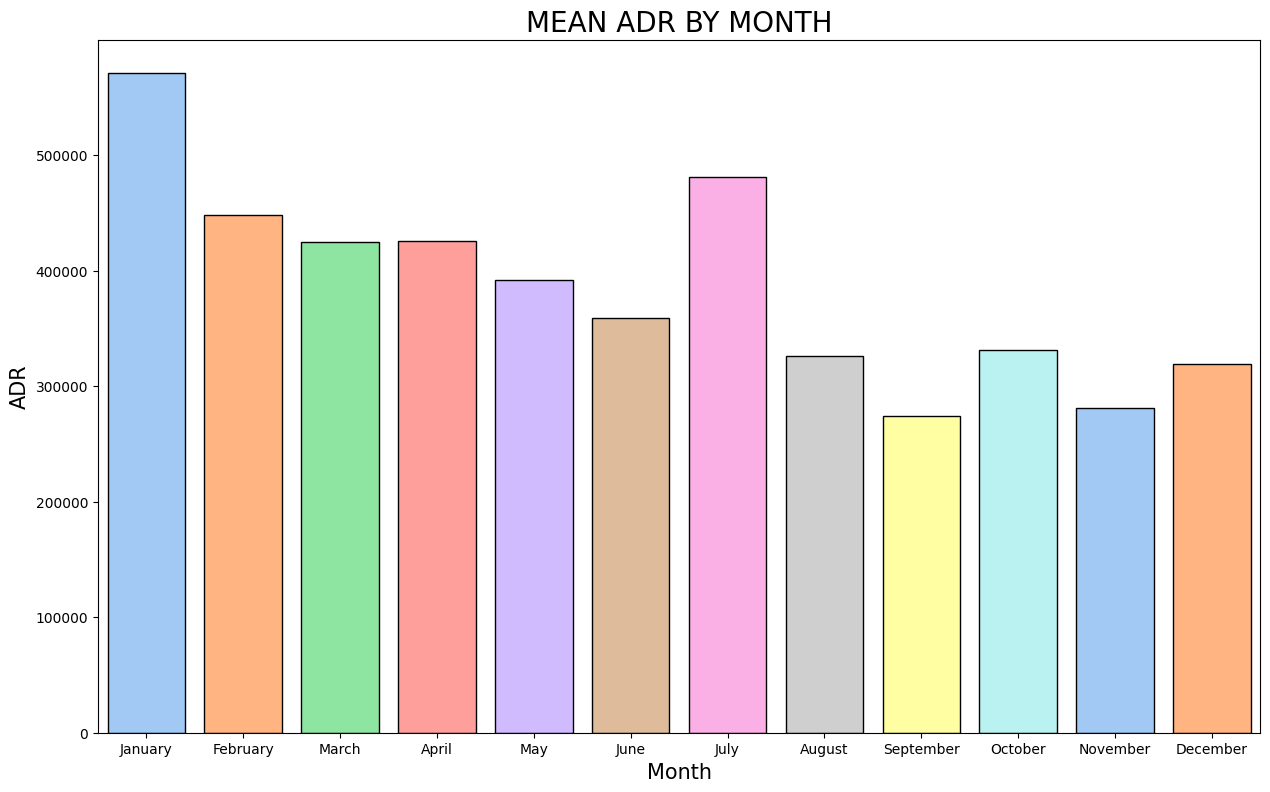

In [54]:
new_data=data[data["is_canceled"]==1].groupby("Month").agg({"adr":"sum"})


plt.figure(figsize=(15,9))
sns.barplot(data=new_data,x=new_data.index,y="adr",order=month_order,palette="pastel",saturation=2,edgecolor="black")
plt.xlabel("Month",fontsize=15)
plt.ylabel("ADR",fontsize=15)
plt.title("MEAN ADR BY MONTH",fontsize=20)
plt.show()

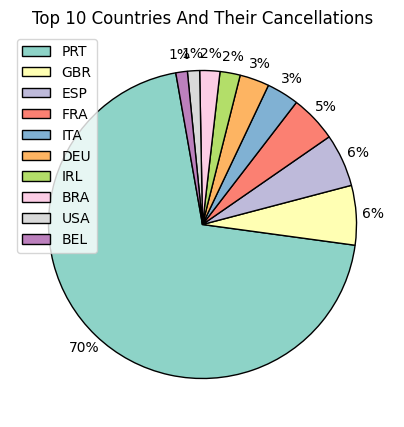

In [41]:
top_10_countries = data[data["is_canceled"] == 1]
top_10_countries=top_10_countries["country"].value_counts()[:10]

colors = sns.color_palette("Set3")
plt.figure(figsize=(5,5))
plt.pie(top_10_countries,autopct="%1.f%%",startangle=100,wedgeprops={"edgecolor":"black"},pctdistance=1.11,colors=colors)
plt.legend(labels=top_10_countries.index)
plt.title("Top 10 Countries And Their Cancellations")
plt.show()

In [42]:
data["market_segment"].value_counts(normalize=True)

,proportion
market_segment,
Online TA,0.474377
Offline TA/TO,0.203193
Groups,0.166581
Direct,0.104696
Corporate,0.042987
Complementary,0.006173
Aviation,0.001993


In [43]:
cancel_data["market_segment"].value_counts(True)*100

,proportion
market_segment,
Online TA,46.969560
Groups,27.398532
Offline TA/TO,18.746603
Direct,4.348614
Corporate,2.215075
Complementary,0.203841
Aviation,0.117775


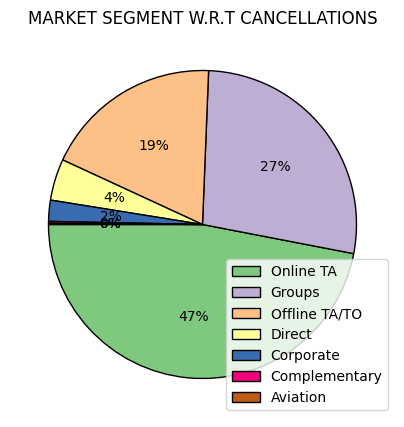

In [44]:
new_data=cancel_data["market_segment"].value_counts(True)*100
colors = sns.color_palette("Accent")
plt.figure(figsize=(5,5))
plt.pie(new_data,autopct="%1.f%%",startangle=180,wedgeprops={"edgecolor":"black"},textprops={"color":"black","size":10},colors=colors)
plt.legend(labels=new_data.index,loc="best")
plt.title("MARKET SEGMENT W.R.T CANCELLATIONS")
plt.show()

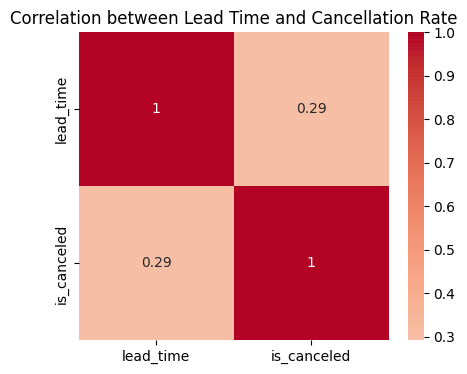

In [45]:
corr_matrix=data[["lead_time","is_canceled"]].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between Lead Time and Cancellation Rate')
plt.show()

In [46]:
data.to_csv("Processed_Data.csv",index=False)